
# Estrategia de **Direct Forecasting**

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, os, warnings
sys.path.append(os.path.abspath('..'))
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.cloud import bigquery

from pre_procesado.common_pipeline import run_global_pipeline
from pre_procesado.direct_forecasting_pipeline import DirectForecastingWrapper
from utils_entrenamiento import walk_forward_split, plot_shap_summary, get_shap_feature_importance


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. Carga de datos desde BigQuery

In [ ]:
client = bigquery.Client(project="project3grupo1")
query = """
WITH listings_dedup AS (
    SELECT *
    FROM `project3grupo1.airbnb_raw.listings`
    QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY snapshot_date DESC) = 1
),
events_agg AS (
    SELECT start_date,
           COUNTIF(category = 'sports')   AS num_sports,
           COUNTIF(category = 'festivals') AS num_festivals,
           SUM(phq_attendance)             AS total_attendance
    FROM `project3grupo1.airbnb_features.events`
    GROUP BY start_date
),
holidays_valencia AS (
    SELECT DISTINCT date
    FROM `project3grupo1.airbnb_features.holidays`
    WHERE applies_to_valencia = True
),
calendar_dates AS (SELECT DISTINCT date FROM `project3grupo1.airbnb_raw.calendar`),
days_to_holiday AS (
    SELECT cd.date,
           MIN(DATE_DIFF(h.date, cd.date, DAY)) AS days_to_next_holiday
    FROM calendar_dates cd
    LEFT JOIN holidays_valencia h ON h.date >= cd.date
    GROUP BY cd.date
)
SELECT
    c.listing_id,
    CASE WHEN c.available = False THEN 1 ELSE 0 END AS is_occupied,
    c.date,
    EXTRACT(MONTH      FROM c.date) AS month,
    EXTRACT(DAYOFWEEK  FROM c.date) AS day_of_week,
    IF(EXTRACT(DAYOFWEEK FROM c.date) IN (1,7), 1, 0) AS is_weekend,
    COALESCE(dh.days_to_next_holiday, 0)  AS days_to_next_holiday,
    IF(h.date IS NOT NULL, 1, 0)          AS is_holiday,
    l.neighbourhood_cleansed,
    l.room_type,
    l.accommodates,
    l.price                AS listing_price,
    l.minimum_nights,
    l.number_of_reviews,
    l.review_scores_rating,
    IF(l.number_of_reviews > 0, 1, 0) AS has_reviews,
    l.instant_bookable,
    w.temp_mean,
    w.precipitation_mm,
    COALESCE(e.num_sports,       0) AS num_sports,
    COALESCE(e.num_festivals,    0) AS num_festivals,
    COALESCE(e.total_attendance, 0) AS total_attendance
FROM `project3grupo1.airbnb_raw.calendar` c
LEFT JOIN listings_dedup                       l  ON c.listing_id = l.id
LEFT JOIN `project3grupo1.airbnb_features.weather` w ON c.date = w.date
LEFT JOIN events_agg                           e  ON c.date = e.start_date
LEFT JOIN holidays_valencia                    h  ON c.date = h.date
LEFT JOIN days_to_holiday                      dh ON c.date = dh.date
WHERE c.date <= '2026-05-19'
QUALIFY ROW_NUMBER() OVER (PARTITION BY c.listing_id, c.date ORDER BY c.date DESC) = 1
"""
df_raw = client.query(query).to_dataframe()


## 1. Pipeline Global + Particiones Temporales

In [ ]:
df_processed = run_global_pipeline(df_raw, max_lag=14)

folds = walk_forward_split(
    df_processed,
    date_col='date',
    n_folds=3,
    val_months=1,
    min_train_months=8)


🔧 PIPELINE GLOBAL (FASE 1)
[Duplicados] Eliminadas 0 filas (0.00%). Retenidas: 3376585
[MNAR Flags] Creadas 1 variables indicadoras: ['is_missing_review_scores_rating']
[Lags Individuales] Creados 13 lags (2 a 14) sobre 'is_occupied' agrupados por listing_id.
[Rachas] Creadas 'streak_occupied' y 'streak_vacant' con shift(2).
[Barrio Features] Creadas: 'occ_barrio_ayer', 'occ_barrio_ma7', 'price_ratio_barrio'.
[Binarización] Variables residuales (room_type, instant_bookable) binarizadas.

------------------------------------------------------------
✅ Pipeline Global completado.
   Filas: 3376585 -> 3376585 | Columnas nuevas: +19
   Shape final: (3376585, 41)
  Fold 1: Train [2025-06..2026-01] (2,051,101 rows) | Val [2026-02..2026-02] (343,644 rows)
  Fold 2: Train [2025-06..2026-02] (2,394,745 rows) | Val [2026-03..2026-03] (380,463 rows)
  Fold 3: Train [2025-06..2026-03] (2,775,208 rows) | Val [2026-04..2026-04] (368,190 rows)
[Walk-Forward] Generados 3 folds temporales.


## 2. Evaluación Walk-Forward — Direct Forecasting

In [ ]:
COLUMNAS_BASURA = [
    'month', 
    'is_entire_home', 
    'occ_barrio_ma7',
    'day_of_week', 
    'is_weekend', 
    'is_holiday', 
    'has_reviews',
    'instant_bookable', 
    'precipitation_mm', 
    'num_sports', 
    'num_festivals', 
    'total_attendance', 
    'is_missing_review_scores_rating',
    'occ_barrio_ayer',
    'is_occupied_lag_3', 'is_occupied_lag_4', 'is_occupied_lag_5', 
    'is_occupied_lag_6', 'is_occupied_lag_7', 'is_occupied_lag_8', 
    'is_occupied_lag_9', 'is_occupied_lag_10', 'is_occupied_lag_11', 
    'is_occupied_lag_12', 'is_occupied_lag_13', 'is_occupied_lag_14']


wrapper = DirectForecastingWrapper(
    n_estimators=300,
    top_k_lags=5,
    mi_sample_frac=0.3,
    random_state=42,
    pruned_features=COLUMNAS_BASURA
)

df_resultados = wrapper.evaluate(df_processed, folds, verbose=True)

print("\n✅ Evaluación completada.")



───────────────────────────────────────────────────────
[Direct Forecasting] Fold 1/3
[Pipeline Árboles] Construido: TreePreprocessor (Sin escalado, NaNs nativos).
🌲 [TreePreprocessor] Ejecutando fit: Seleccionando features...
[MI Lags] Top 5 lags seleccionados: ['is_occupied_lag_2']
          Scores: {'is_occupied_lag_2': 0.3148}
  h=1 → AUC 0.9779 | F1 0.8773 | Brier 0.0465
[Pipeline Árboles] Construido: TreePreprocessor (Sin escalado, NaNs nativos).
🌲 [TreePreprocessor] Ejecutando fit: Seleccionando features...
[MI Lags] Top 5 lags seleccionados: ['is_occupied_lag_2']
          Scores: {'is_occupied_lag_2': 0.2908}
  h=2 → AUC 0.9745 | F1 0.8715 | Brier 0.0492
[Pipeline Árboles] Construido: TreePreprocessor (Sin escalado, NaNs nativos).
🌲 [TreePreprocessor] Ejecutando fit: Seleccionando features...
[MI Lags] Top 5 lags seleccionados: ['is_occupied_lag_2']
          Scores: {'is_occupied_lag_2': 0.2806}
  h=3 → AUC 0.9718 | F1 0.8671 | Brier 0.0513
[Pipeline Árboles] Construido: Tre

## 3. Reporte de Degradación por Horizonte

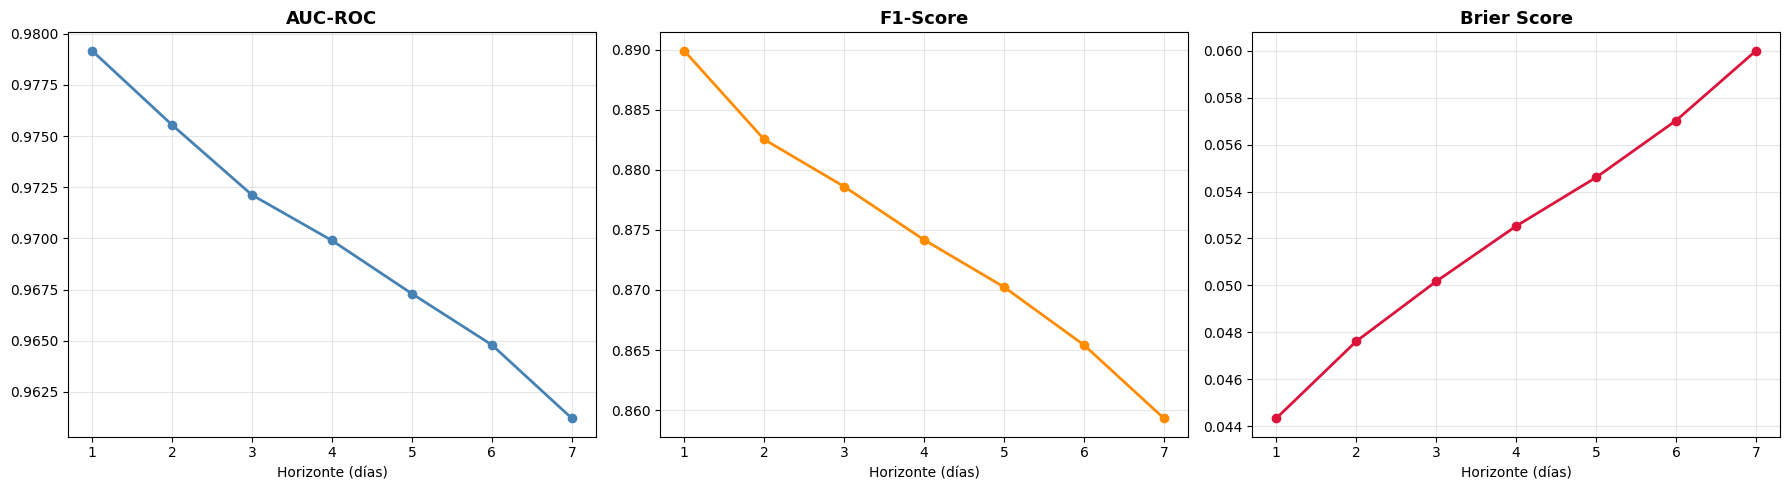

In [ ]:
df_avg = (
    df_resultados
    .groupby('Horizonte')[['AUC', 'F1', 'Accuracy', 'Precision', 'Recall', 'Brier']]
    .mean()
    .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('AUC', 'AUC-ROC', 'steelblue'), ('F1', 'F1-Score', 'darkorange'), ('Brier', 'Brier Score', 'crimson')]

for ax, (met, label, color) in zip(axes, metrics):
    ax.plot(df_avg['Horizonte'], df_avg[met], marker='o', color=color, linewidth=2)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Horizonte (días)')
    ax.set_xticks(range(1, 8))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


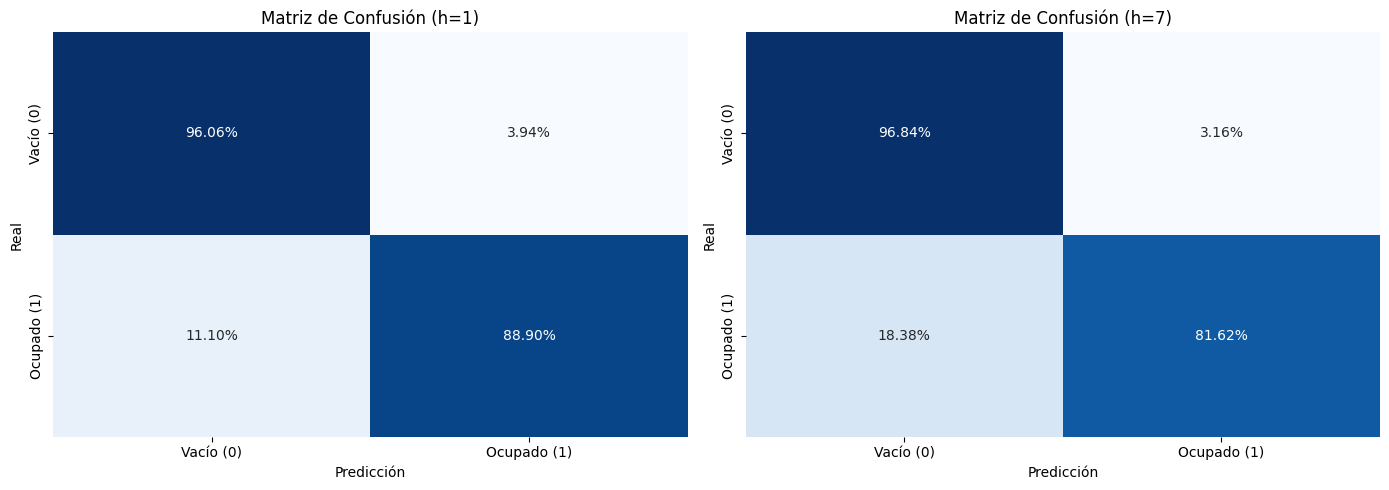

In [ ]:
import matplotlib.pyplot as plt
from utils_entrenamiento import plot_confusion_matrix

# 1. Crear la figura con 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2. Horizonte h=1
df_h1 = df_val.dropna(subset=['is_occupied_target_h1'])
y_true_1 = df_h1['is_occupied_target_h1']
y_pred_1 = wrapper.models_[1].predict(wrapper.pipelines_[1].transform(_build_feature_matrix(df_h1)))
plot_confusion_matrix(y_true_1, y_pred_1, title_suffix='(h=1)', ax=axes[0])

# 3. Horizonte h=7
df_h7 = df_val.dropna(subset=['is_occupied_target_h7'])
y_true_7 = df_h7['is_occupied_target_h7']
y_pred_7 = wrapper.models_[7].predict(wrapper.pipelines_[7].transform(_build_feature_matrix(df_h7)))
plot_confusion_matrix(y_true_7, y_pred_7, title_suffix='(h=7)', ax=axes[1])

plt.tight_layout()
plt.show()


## 4. Explicabilidad con SHAP
Importancia de las variables en cada h


🔍 Horizonte h=1


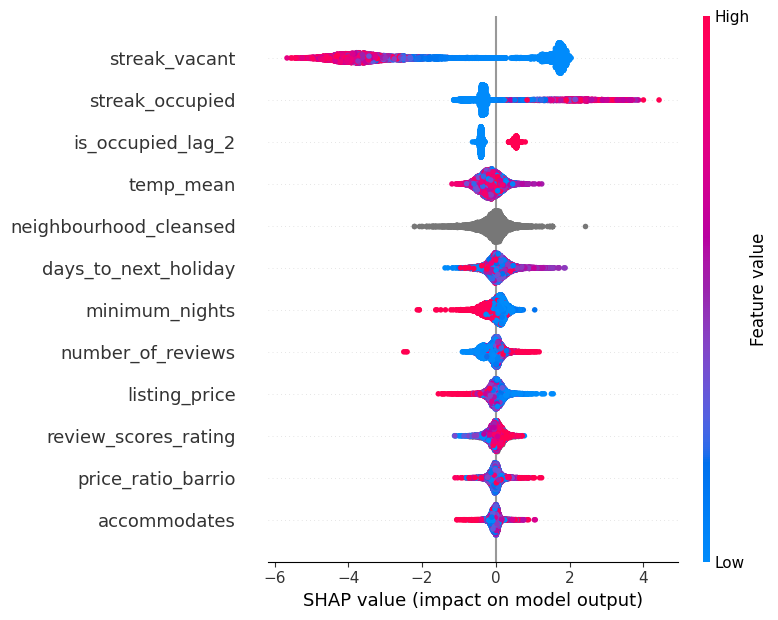


🔍 Horizonte h=7


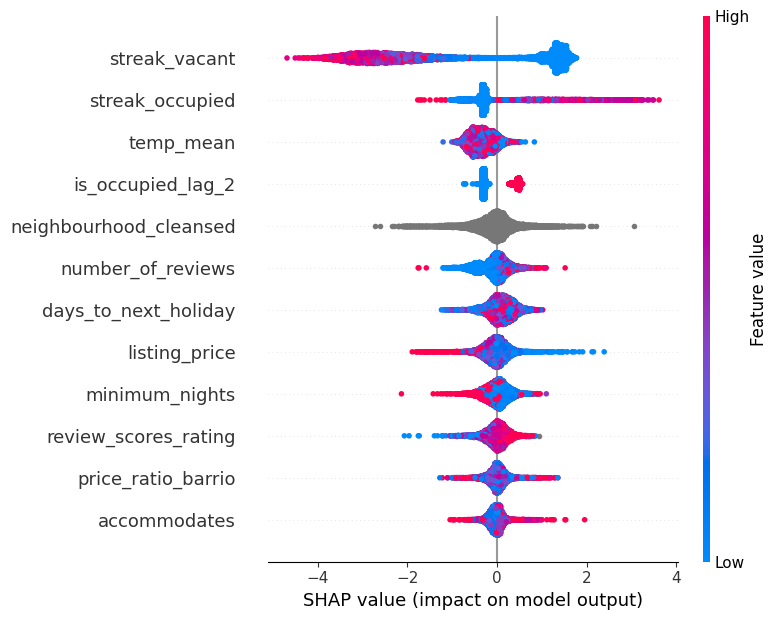

In [ ]:
import shap
from pre_procesado.direct_forecasting_pipeline import _build_feature_matrix, _generate_shifted_targets

# 1. Asegurar targets
if 'is_occupied_target_h1' not in df_processed.columns:
    df_processed = _generate_shifted_targets(df_processed)

# 2. Datos de validación
_, val_idx = folds[-1]
df_val = df_processed.loc[val_idx]

for h in [1, 7]:
    print(f"\n🔍 Horizonte h={h}")
    target_h = f'is_occupied_target_h{h}'
    df_h = df_val.dropna(subset=[target_h])
    
    X_raw = _build_feature_matrix(df_h)
    X_tree = wrapper.pipelines_[h].transform(X_raw)
    
    # 3. Muestreo 10k
    X_sample = X_tree.sample(min(10000, len(X_tree)), random_state=42)
    
    # 4. Cálculo manual de SHAP
    explainer = shap.TreeExplainer(wrapper.models_[h])
    shap_explanation = explainer(X_sample, check_additivity=False)
    
    if len(shap_explanation.shape) == 3:
        shap_explanation = shap_explanation[:, :, 1]
    
    shap.summary_plot(shap_explanation, X_sample, max_display=15, show=True)


## 5. Serialización Final

In [ ]:
os.makedirs('artefactos', exist_ok=True)
joblib.dump(wrapper, 'artefactos/direct_forecasting_model_t7.joblib')

['artefactos/direct_forecasting_model_t7.joblib']